# 1. Contexto del problema

Este capítulo acompaña la primera pestaña del dashboard. Allí se presenta el problema que
estudiamos, de dónde salen los datos y con qué variables se trabaja. Aquí explicamos cada elemento de
esa pestaña y añadimos los detalles de la base de datos que no caben en el dashboard.

In [1]:
from informe import *

# Resumen de la partición: es la base de varias cifras que se citan en este capítulo
res = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Prueba", "Total"],
    "adultos": [len(TRAIN), len(TEST), len(TRAIN) + len(TEST)],
    "con dificultad": [TRAIN[OBJETIVO].sum(), TEST[OBJETIVO].sum(), TRAIN[OBJETIVO].sum() + TEST[OBJETIVO].sum()],
})
res["prevalencia"] = res["con dificultad"] / res["adultos"]
ver(res, {"adultos": "{:,.0f}", "con dificultad": "{:,.0f}", "prevalencia": "{:.2%}"})

conjunto,adultos,con dificultad,prevalencia
Entrenamiento,"44,903","9,253",20.61%
Prueba,"11,226","2,313",20.60%
Total,"56,129","11,566",20.61%


## 1.1 El problema en una pregunta

La parte superior de la pestaña resume el problema en una frase y en cuatro cifras. La dificultad
cognitiva subjetiva (DCS) es la sensación de la propia persona de que le cuesta recordar o
concentrarse, aunque una prueba clínica no lo confirme. Importa porque suele aparecer antes que el
deterioro que sí se mide: los metaanálisis que citamos (Mitchell et al., 2014; Wang et al., 2021) ubican
el riesgo de desarrollar demencia en alrededor del doble para quienes la reportan, y de ahí sale la
cifra «≈ 2×» del dashboard. La cifra «≈ 45 %» viene de la Comisión Lancet 2024, que estima que cerca de
esa proporción de los casos de demencia se asocia a 14 factores de riesgo que en principio se pueden
modificar (Livingston et al., 2024).

Las otras dos tarjetas no son citas sino resultados de nuestra base. Trabajamos con 56.129 adultos de la
NHIS y, en el conjunto de entrenamiento que usa el dashboard, el 20,6 % responde que tiene alguna
dificultad para recordar o concentrarse. Esa prevalencia es la referencia contra la que se mide
todo lo demás: un modelo que no sepa nada de las personas y solo conozca ese porcentaje acertaría, en
términos de precisión sobre los casos, apenas una de cada cinco veces.

La pregunta de investigación es la misma del primer entregable: qué tan bien los factores de riesgo
modificables y el antecedente de ACV permiten predecir la DCS. Hay una precisión de alcance que vale la
pena repetir porque condiciona cómo se leen todos los resultados. Los datos son de corte transversal,
es decir, cada persona se midió una sola vez. El modelo, por lo tanto, no anticipa quién va a deteriorarse,
sino qué tan bien el perfil de factores de riesgo señala a quienes hoy dicen tener dificultades.
Es una prueba de concepto sobre cuánta información útil hay en esas variables.

Los cuatro objetivos específicos de la pestaña se corresponden con los capítulos del informe: caracterizar
la prevalencia y sus asociaciones (capítulo 2), identificar la fuga de información (capítulo 2, sección
de auditoría), entrenar los modelos base y compararlos con un clasificador trivial (capítulo 3) e
interpretar la contribución de cada factor mediante odds ratios, con atención al ACV (capítulos 2 y 3).

## 1.2 De dónde salen los datos

### Recorrido de la muestra

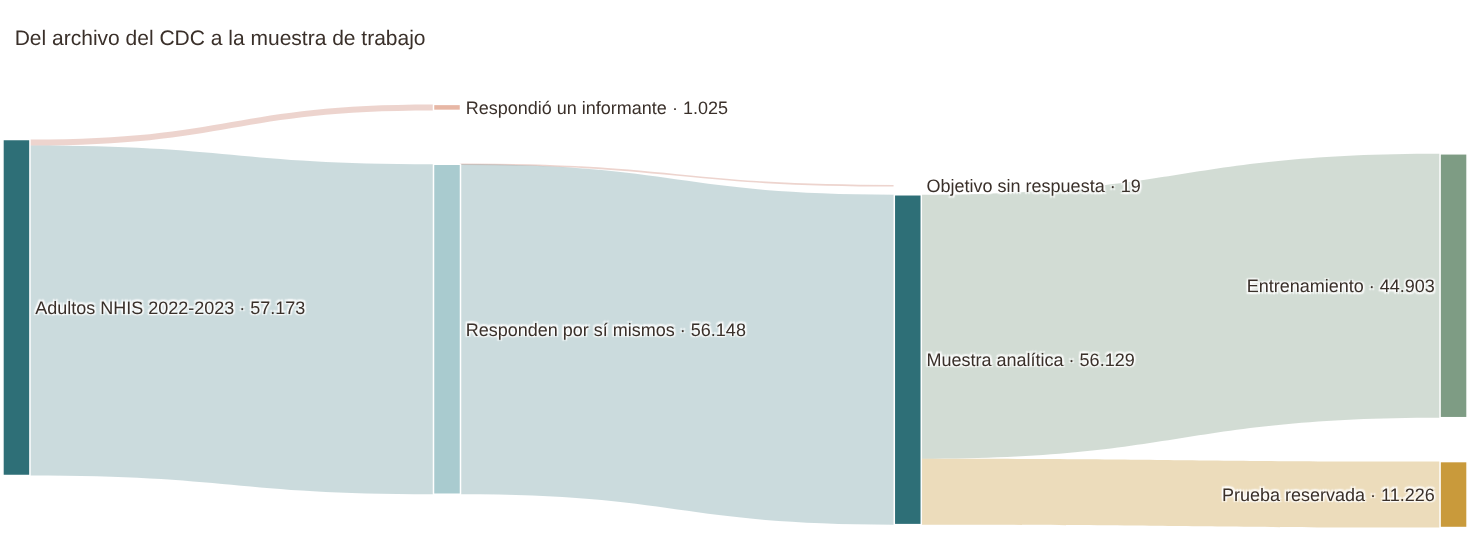

In [2]:
mostrar(F.fig_flujo_muestra(), alto=360)

El diagrama de flujo sigue a los adultos desde los archivos del CDC hasta los conjuntos de trabajo.
Entre 2022 y 2023 la encuesta entrevistó a 57.173 adultos. De ellos salen 1.025 (1,8 %) porque la
entrevista la respondió un informante, por ejemplo un familiar o un cuidador, y 19 más porque la
pregunta objetivo quedó sin respuesta. Excluir a los informantes fue una decisión conceptual: la
variable que queremos predecir es la dificultad que la persona percibe en sí misma, y otra persona
responde desde otro punto de vista. El costo es un sesgo de selección que conviene tener presente, porque
quienes no pudieron contestar por sí mismos probablemente concentran los casos de deterioro más
severo.

Quedan 56.129 adultos en la muestra analítica. La reserva del conjunto de prueba se hizo en ese punto, antes de mirar
cualquier relación entre variables: 44.903 adultos para entrenar y explorar, y 11.226 que no se tocan
hasta evaluar los modelos. La partición es estratificada por la variable objetivo y por año, por eso la
prevalencia es prácticamente la misma en los dos conjuntos (20,6 %, tabla anterior). Como hay un solo
adulto por hogar, no existe riesgo de que una misma familia quede repartida entre entrenamiento y prueba.

Esta separación explica una convención que se mantiene en todo el dashboard: la pestaña de EDA usa
únicamente el conjunto de entrenamiento, y el conjunto de prueba solo aparece en la pestaña de modelos.

### Cobertura del marco Lancet 2024

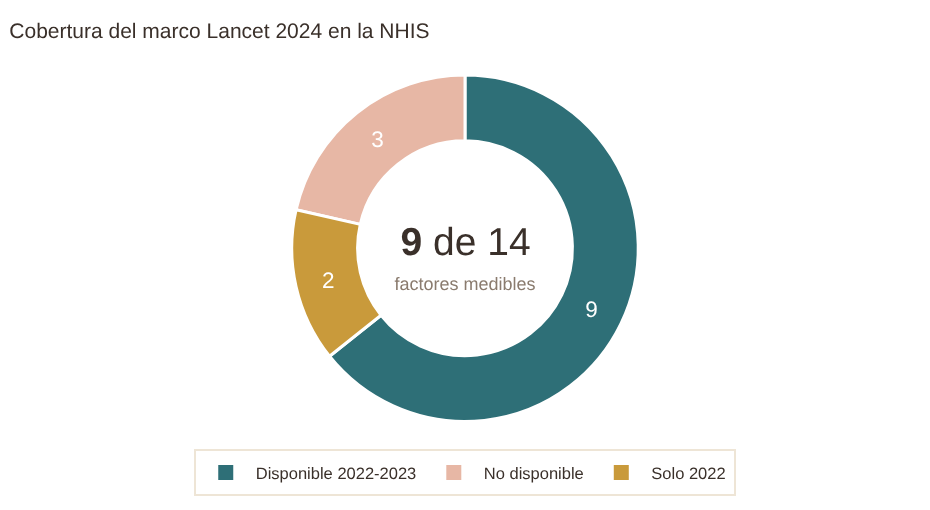

Factor de riesgo (Lancet 2024),Disponibilidad,Variable(s) en la base,Cómo se mide
Baja escolaridad,Disponible 2022-2023,educacion,Máximo nivel educativo (5 categorías)
Hipertensión,Disponible 2022-2023,hipertension,Diagnóstico alguna vez
Colesterol LDL alto,Disponible 2022-2023,colesterol_alto,Colesterol alto diagnosticado alguna vez
Diabetes,Disponible 2022-2023,diabetes,Diagnóstico alguna vez
Depresión,Disponible 2022-2023,"depresion_dx, frecuencia_depresion",Diagnóstico y frecuencia de síntomas
Pérdida auditiva,Disponible 2022-2023,dificultad_auditiva,"Dificultad para oír, aun con audífonos"
Pérdida visual,Disponible 2022-2023,dificultad_visual,"Dificultad para ver, aun con gafas"
Tabaquismo,Disponible 2022-2023,tabaquismo,"Nunca, exfumador o fumador actual"
Obesidad,Disponible 2022-2023,imc_categoria,Categoría de IMC (peso y talla autorreportados)
Consumo excesivo de alcohol,Solo 2022,—,Se preguntó solo en 2022


In [3]:
mostrar(F.fig_lancet_dona(), ancho=620, alto=340)
ver(F.TABLA_LANCET)

La dona resume la tabla: de los 14 factores del marco Lancet, la NHIS mide 9 con las mismas preguntas
en 2022 y 2023 (escolaridad, hipertensión, colesterol, diabetes, depresión, pérdida auditiva, pérdida
visual, tabaquismo y obesidad). El consumo excesivo de alcohol y la inactividad física solo se preguntaron
en 2022, y el aislamiento social, el traumatismo craneoencefálico y la contaminación del aire no
tienen una medición comparable.

Podríamos haber incluido los dos factores de un solo año, pero habría obligado a descartar la mitad de la
muestra o a imputar un año completo de datos, y ninguna de las dos cosas nos pareció razonable. Lo
declaramos como limitación: el modelo ve cerca de dos tercios del marco, y las variables que faltan
(sobre todo la actividad física y el aislamiento social) podrían explicar parte de la información que el modelo no
logra capturar. En la tabla, la columna «Variable(s) en la base» deja ver que la depresión entra por
dos vías, el diagnóstico y la frecuencia de síntomas, algo que más adelante resulta clave.

### Mapa de variables

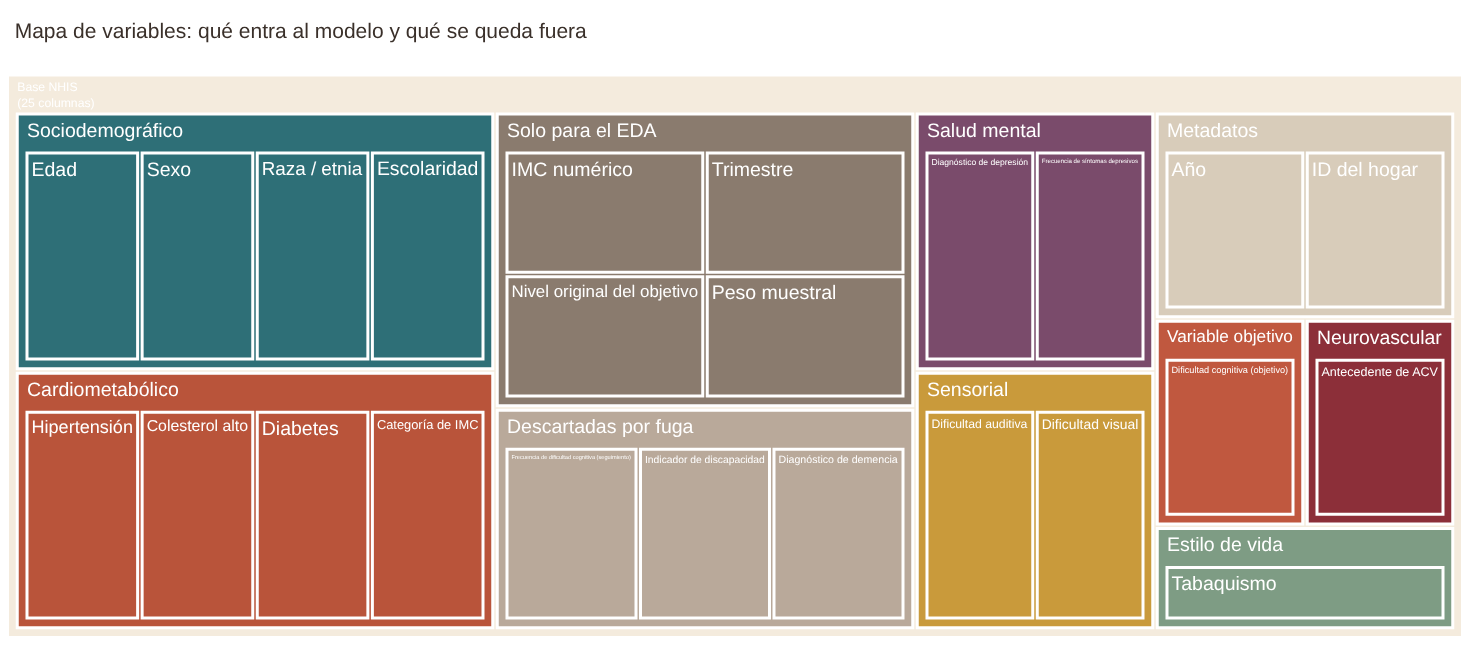

rol,columnas
Auditoría de fuga,3
Estratificación,1
Identificador,1
Objetivo,1
Predictora,14
Solo EDA,4


In [4]:
mostrar(F.fig_mapa_variables(), alto=430)
roles = DICCIONARIO.groupby("rol").size().rename("columnas").reset_index()
ver(roles)

El mapa de variables es la versión visual del diccionario de datos. Cada rectángulo es una de las 25
columnas de la base y los colores separan lo que entra al modelo de lo que no. Las 14 predictoras se
agrupan por afinidad temática: sociodemográficas (edad, sexo, raza o etnia y escolaridad),
cardiometabólicas (hipertensión, colesterol, diabetes e IMC), salud mental (diagnóstico de depresión y
frecuencia de síntomas), sensoriales (audición y visión), neurovascular (ACV) y estilo de vida
(tabaquismo). Fuera de las predictoras quedan la variable objetivo, las variables que solo se usan en el
análisis exploratorio (como el IMC numérico y el peso muestral), los metadatos (año, trimestre e
identificador del hogar) y las tres variables descartadas por fuga.

Esas tres merecen mención aparte porque muestran que el diccionario no es un trámite. La pregunta de
seguimiento sobre la frecuencia de la dificultad solo se le hace a quien respondió que sí tiene dificultad,
de modo que contiene al objetivo. El indicador de discapacidad del Washington Group se construye
con seis preguntas, una de ellas la pregunta objetivo. Y el diagnóstico de demencia es, por definición,
un deterioro cognitivo y no un factor de riesgo. Las tres se auditan con números en el capítulo 2.

Al pasar el cursor por cada rectángulo, el dashboard muestra el nombre original de la variable en la NHIS y
su significado. Es útil para quien quiera verificar una variable contra el codebook de la encuesta.

### Diccionario de variables

In [5]:
cols = ["variable", "variable_nhis", "rol", "tipo", "unidad_categorias", "factor_lancet_2024"]
ver(DICCIONARIO[cols].rename(columns={"variable_nhis": "variable NHIS", "unidad_categorias": "valores", "factor_lancet_2024": "factor Lancet"}))

variable,variable NHIS,rol,tipo,valores,factor Lancet
dificultad_cognitiva,COGMEMDFF_A,Objetivo,Binaria,"0 = ninguna; 1 = alguna, mucha o no puede",—
edad,AGEP_A,Predictora,Numérica discreta,Años (18-84; 85 = 85 o más),No (confusor)
sexo,SEX_A,Predictora,Nominal binaria,Hombre / Mujer,No (confusor)
raza_etnia,HISPALLP_A,Predictora,Nominal (7),Grupos raciales y origen hispano,No (confusor)
educacion,EDUCP_A,Predictora,Ordinal (5),Menos que secundaria … Posgrado,Sí: baja escolaridad
hipertension,HYPEV_A,Predictora,Binaria,Sí / No,Sí: hipertensión
colesterol_alto,CHLEV_A,Predictora,Binaria,Sí / No,Sí: colesterol LDL alto
diabetes,DIBEV_A,Predictora,Binaria,Sí / No,Sí: diabetes
acv,STREV_A,Predictora,Binaria,Sí / No,No (exposición de interés)
depresion_dx,DEPEV_A,Predictora,Binaria,Sí / No,Sí: depresión


La tabla del dashboard permite filtrar por rol y buscar texto en cualquier columna; aquí aparece
completa, sin el significado de cada variable para no ensanchar la página. Dos columnas conviene leerlas con cuidado. La de
«valores» indica cómo quedó codificada cada variable después de pasar por el codebook (por ejemplo, la
escolaridad se agrupó de diez niveles a cinco), y la de «factor Lancet» aclara cuáles variables corresponden a
un factor del marco y cuáles son de ajuste. La edad, el sexo y la raza o etnia no son factores modificables,
pero se mantienen como variables de ajuste porque están asociadas tanto con la exposición como con el
resultado.

## 1.3 Ruta del proyecto

La parte final de la pestaña ubica este entregable en el proyecto completo. El primer entregable cubrió la
base de datos, el análisis exploratorio, la auditoría de fuga y el modelo base. Este segundo
entregable lo vuelve interactivo y añade una SVM lineal como segundo modelo de referencia. Las siguientes
entregas deberían probar modelos que capturen no linealidades e interacciones, hacer un análisis de
sensibilidad sin las variables que dejamos «en observación» y evaluar la equidad del desempeño entre grupos.

## 1.4 Detalles que el dashboard no muestra

### Consideraciones éticas

Los archivos de uso público de la NHIS no traen nombres, direcciones ni fechas exactas; el identificador de
hogar es aleatorio y no se puede enlazar entre años. El CDC además trunca la edad en 85 años, suprime los
pesos y tallas extremos y agrupa las categorías raras para reducir el riesgo de reidentificación. Nosotros
no añadimos nada que lo aumente y respetamos la condición de uso de no intentar identificar a los
participantes.

La raza y la etnia se usan como variable de ajuste porque la literatura documenta diferencias en la
exposición a los factores de riesgo, pero en un modelo predictivo pueden perpetuar inequidades. Por eso
sus coeficientes se leen con cautela y dejamos pendiente la evaluación del desempeño por subgrupo.
El simulador del dashboard lleva un aviso por la misma razón: el modelo no es una herramienta
diagnóstica, se entrenó con adultos de Estados Unidos y estima la probabilidad de *reportar* dificultad
cognitiva, no de tener demencia.

### Qué cambia respecto al Entregable 1

- Los números de entrenamiento y prueba son los mismos y los resultados de la regresión logística se
  reproducen: PR-AUC de 0,538 y ROC-AUC de 0,804 en prueba, umbral de 0,246 y C = 1.
- Se agrega la SVM lineal como segundo modelo base (capítulo 3).
- El PCA del dashboard usa las categorías después de agrupar las raras, igual que el pipeline del modelo.
  Por eso aquí resultan 28 componentes (16 para llegar al 80 % de la varianza) y no las 32 y 22 del primer
  entregable, que codificaba las categorías raras por separado. La conclusión es la misma y se discute en el
  capítulo 2.